<a href="https://colab.research.google.com/github/M4rwaneX/AAA_project/blob/main/projet/projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl
import plotly.express as px
import torch

In [2]:
url = "https://raw.githubusercontent.com/M4rwaneX/AAA_project/main/dataset/games.csv"
dataset = pd.read_csv(url)

In [3]:
print(list(dataset.columns))
print(dataset.head(2))
print(dataset.info())

cols_keep = [
    'rated', 'created_at', 'last_move_at', 'turns',
    'white_rating', 'black_rating', 'opening_ply',
    'opening_eco', 'opening_name', 'winner'
]
dataset = dataset[cols_keep].copy()

['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status', 'winner', 'increment_code', 'white_id', 'white_rating', 'black_id', 'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply']
         id  rated    created_at  last_move_at  turns victory_status winner  \
0  TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime  white   
1  l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign  black   

  increment_code  white_id  white_rating   black_id  black_rating  \
0           15+2  bourgris          1500       a-00          1191   
1           5+10      a-00          1322  skinnerua          1261   

                                               moves opening_eco  \
0  d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...         D10   
1  d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...         B00   

                             opening_name  opening_ply  
0        Slav Defense: Exchange Variation            5  
1  Nimzowitsch Defense:

les colonnes que nous allons garder :

['id', 'rated', 'created_at', 'last_move_at', 'turns','increment_code', 'white_id', 'white_rating', 'black_id', 'black_rating', 'opening_eco', 'opening_name', 'opening_ply']

In [4]:
split = skl.model_selection.StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index,test_index in split.split(dataset,dataset["winner"]):
  strat_train_set = dataset.loc[train_index]
  strat_test_set = dataset.loc[test_index]

print(strat_train_set["winner"].value_counts()/len(strat_test_set))

winner
white    1.994267
black    1.815803
draw     0.189432
Name: count, dtype: float64


Text(0, 0.5, 'Fréquence')

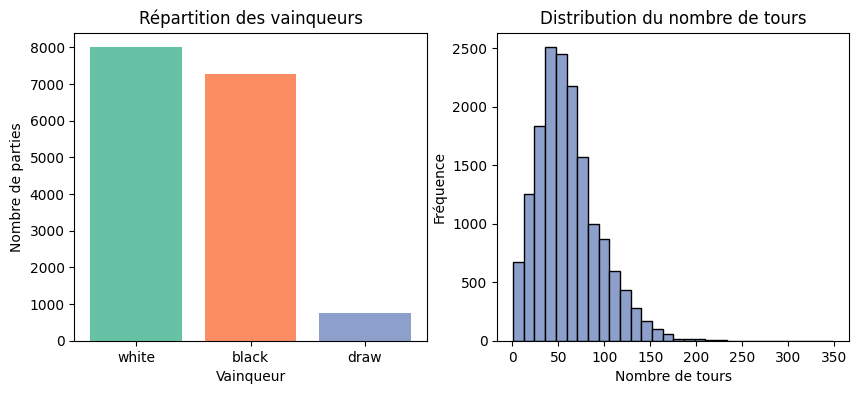

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
counts_winner = strat_train_set["winner"].value_counts()
plt.bar(counts_winner.index, counts_winner.values, color=['#66c2a5', '#fc8d62', '#8da0cb'])
plt.title("Répartition des vainqueurs")
plt.xlabel("Vainqueur")
plt.ylabel("Nombre de parties")
plt.subplot(1,2,2)
plt.hist(strat_train_set["turns"], bins=30, color="#8da0cb", edgecolor="black")
plt.title("Distribution du nombre de tours")
plt.xlabel("Nombre de tours")
plt.ylabel("Fréquence")

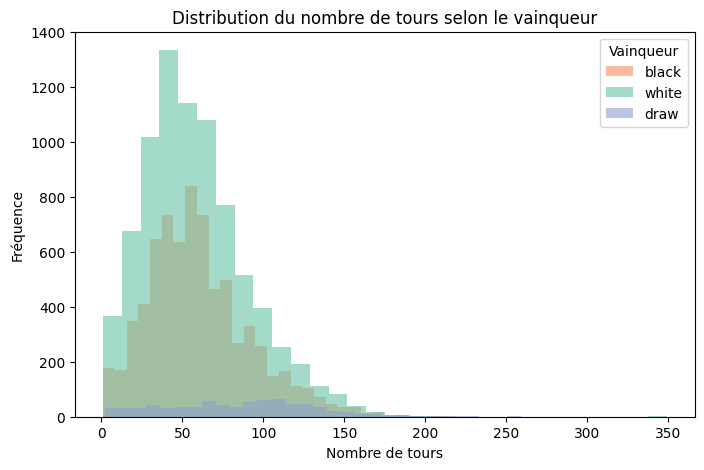

In [ ]:
plt.figure(figsize=(8,5))
winners = strat_train_set["winner"].unique()
colors = {"white": "#66c2a5", "black": "#fc8d62", "draw": "#8da0cb"}

for w in winners:
    subset = strat_train_set[strat_train_set["winner"] == w]
    plt.hist(subset["turns"], bins=30, alpha=0.6, label=w, color=colors.get(w, "gray"))

plt.title("Distribution du nombre de tours selon le vainqueur")
plt.xlabel("Nombre de tours")
plt.ylabel("Fréquence")
plt.legend(title="Vainqueur")
plt.show()


opening_name
Van't Kruijs Opening                             299
Sicilian Defense                                 283
Sicilian Defense: Bowdler Attack                 233
Scandinavian Defense: Mieses-Kotroc Variation    217
French Defense: Knight Variation                 216
Scotch Game                                      214
Queen's Pawn Game: Mason Attack                  190
Queen's Pawn Game: Chigorin Variation            186
Scandinavian Defense                             183
Philidor Defense #3                              169
Name: count, dtype: int64


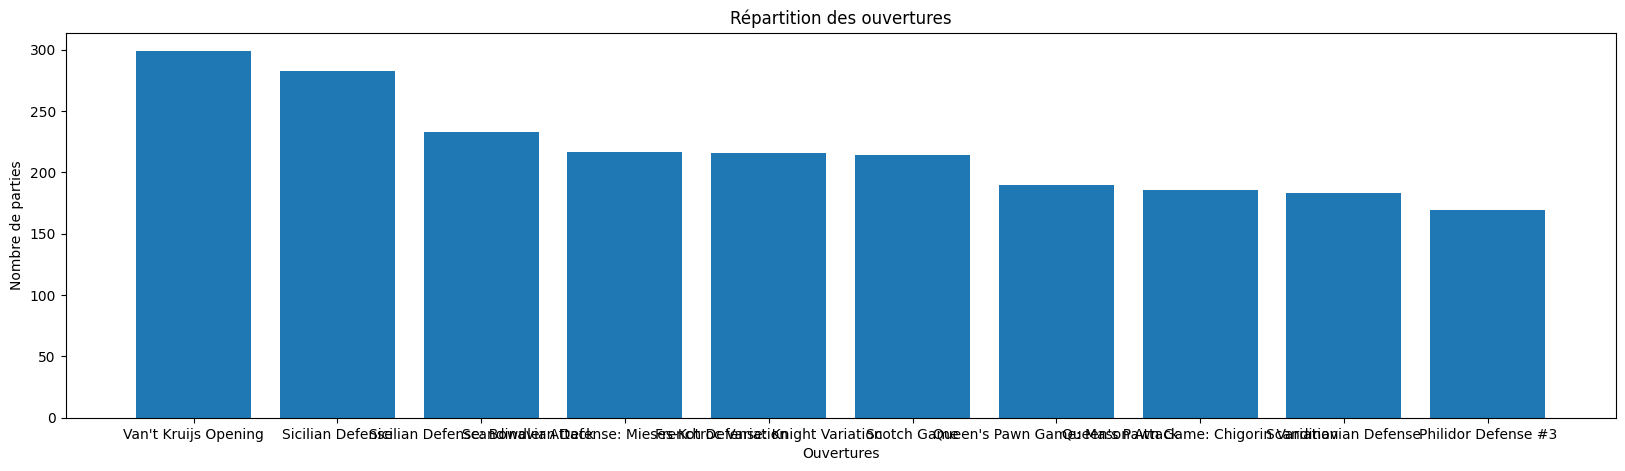

In [ ]:
opening_repartition = strat_train_set['opening_name'].value_counts()
most_common_openings = opening_repartition.head(10)
print(most_common_openings)
plt.figure(figsize=(20,5))

''' plt.bar(most_common_openings.index, most_common_openings.values)
plt.title("Répartition des ouvertures")
plt.xlabel("Ouvertures")
plt.ylabel("Nombre de parties")
plt.show() '''


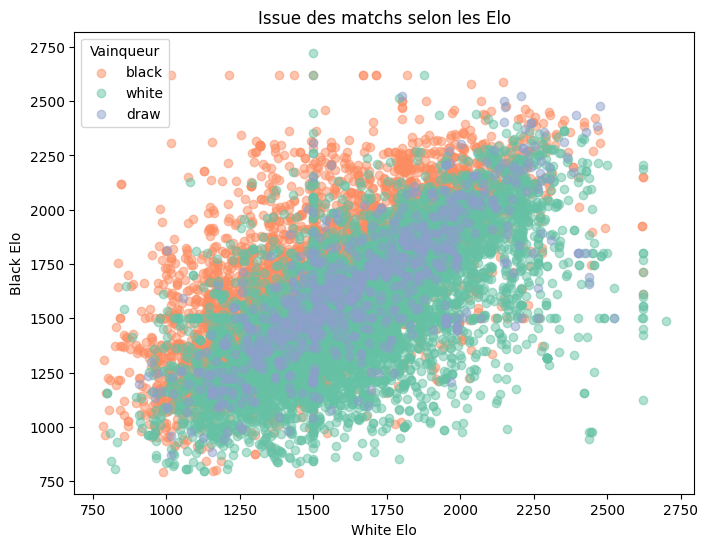

In [ ]:
colors = {"white": "#66c2a5", "black": "#fc8d62", "draw": "#8da0cb"}

plt.figure(figsize=(8,6))
for w in strat_train_set["winner"].unique():
    subset = strat_train_set[strat_train_set["winner"] == w]
    plt.scatter(subset["white_rating"], subset["black_rating"],
                alpha=0.5, label=w, color=colors[w])

plt.xlabel("White Elo")
plt.ylabel("Black Elo")
plt.title("Issue des matchs selon les Elo")
plt.legend(title="Vainqueur")
plt.show()

In [5]:
cols_numeric = ['rated', 'created_at', 'last_move_at', 'turns',
                'white_rating', 'black_rating', 'opening_ply']

cols_categorical = ['opening_eco', 'opening_name']


preprocessor = skl.compose.ColumnTransformer(
    transformers=[
        ('num', skl.preprocessing.StandardScaler(), cols_numeric),
        ('cat', skl.preprocessing.OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cols_categorical)
    ],
    remainder='drop'
)

pipeline = skl.pipeline.Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', skl.ensemble.RandomForestClassifier())
])

In [21]:
x_train = strat_train_set.drop("winner", axis=1, errors='ignore')
y_train = strat_train_set["winner"]

x_test = strat_test_set.drop("winner", axis=1, errors='ignore')
y_test = strat_test_set["winner"]

cv = skl.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = skl.model_selection.cross_val_score(pipeline, x_train, y_train, cv=cv, scoring='accuracy')

print(f"\nAccuracy moyenne (CV 5 folds) : {cv_scores.mean():.2%} ± {cv_scores.std():.2%}")

pipeline.fit(x_train, y_train)
results = pipeline.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u


Accuracy moyenne (CV 5 folds) : 62.75% ± 0.60%


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [22]:
#Encodeur pour renomer résultats
le = skl.preprocessing.LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)
print("Classes :", le.classes_)

Classes : ['black' 'draw' 'white']


In [ ]:
y_test = strat_test_set["winner"]

score = pipeline.score(x_test, y_test)
print(f"Précision : {score:.2%}")

print(skl.metrics.classification_report(y_test, results))

print(skl.metrics.confusion_matrix(y_test, results))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Précision : 64.18%
              precision    recall  f1-score   support

       black       0.63      0.61      0.62      1822
        draw       0.69      0.12      0.20       190
       white       0.65      0.72      0.68      2000

    accuracy                           0.64      4012
   macro avg       0.66      0.48      0.50      4012
weighted avg       0.64      0.64      0.63      4012

[[1119    6  697]
 [  91   22   77]
 [ 562    4 1434]]


<Figure size 5000x3000 with 0 Axes>

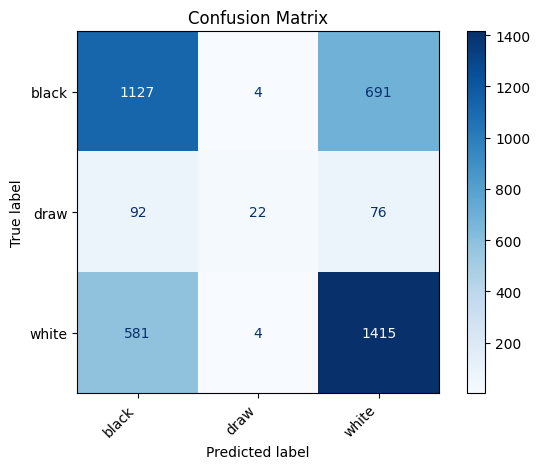

In [23]:

cm = skl.metrics.confusion_matrix(y_test, results)

# Print the confusion matrix with matplotlib to have a better output
plt.figure(figsize=(50, 30))
disp = skl.metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Modele de réseaux de neurones

In [6]:
x_train = strat_train_set.drop("winner", axis=1)
y_train = strat_train_set["winner"]

x_test = strat_test_set.drop("winner", axis=1)
y_test = strat_test_set["winner"]


In [8]:

le = skl.preprocessing.LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)
print("Classes :", le.classes_)


Classes : ['black' 'draw' 'white']


In [11]:
X_train_processed = preprocessor.fit_transform(x_train)
X_test_processed = preprocessor.transform(x_test)

print("Shape X_train :", X_train_processed.shape)

#conversion en tensor pour pytorch
X_train_t = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long)

X_test_t = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_t = torch.tensor(y_test_enc, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
test_dataset = torch.utils.data.TensorDataset(X_test_t, y_test_t)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Shape X_train : (16046, 1753)


In [18]:
class ChessNet(torch.nn.Module):
    def __init__(self, input_dim, hidden=128, num_classes=3):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = ChessNet(input_dim=X_train_processed.shape[1], num_classes=num_classes)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



In [19]:
EPOCHS = 25

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss:.4f}")


Epoch 1/25 - Loss: 201.5956
Epoch 2/25 - Loss: 184.8036
Epoch 3/25 - Loss: 177.5496
Epoch 4/25 - Loss: 170.0494
Epoch 5/25 - Loss: 162.6549
Epoch 6/25 - Loss: 155.0269
Epoch 7/25 - Loss: 148.3258
Epoch 8/25 - Loss: 141.9077
Epoch 9/25 - Loss: 136.0072
Epoch 10/25 - Loss: 130.6075
Epoch 11/25 - Loss: 125.8764
Epoch 12/25 - Loss: 120.9171
Epoch 13/25 - Loss: 116.7309
Epoch 14/25 - Loss: 112.4071
Epoch 15/25 - Loss: 108.8367
Epoch 16/25 - Loss: 105.2350
Epoch 17/25 - Loss: 102.0223
Epoch 18/25 - Loss: 97.9261
Epoch 19/25 - Loss: 95.6601
Epoch 20/25 - Loss: 92.9027
Epoch 21/25 - Loss: 89.5086
Epoch 22/25 - Loss: 86.7779
Epoch 23/25 - Loss: 84.9750
Epoch 24/25 - Loss: 82.1591
Epoch 25/25 - Loss: 80.4058



Accuracy test = 57.50%


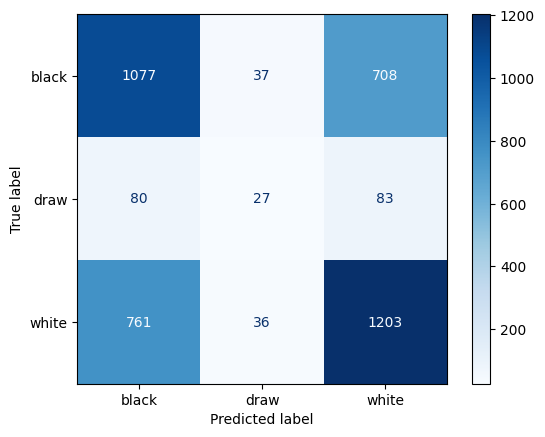

In [26]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for Xb, yb in test_loader:
        preds = model(Xb)
        predicted = preds.argmax(1)
        total += len(yb)
        correct += (predicted == yb).sum().item()

accuracy = correct / total
print(f"\nAccuracy test = {accuracy:.2%}")


preds_test = model(X_test_t).argmax(1)
cm = skl.metrics.confusion_matrix(y_test_enc, preds_test)

disp = skl.metrics.ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.show()
